# FeedbackIQ: Phase 4 — Aspect Extraction & Customer Complaint Analysis
**Project**: Customer Feedback & Sentiment Analysis System  
**Stage**: Phase 4 — Fine-Grained Multi-Label Aspect Extraction  
**Dataset**: Amazon Reviews 2023 (`Electronics` & `Fashion` Negative Reviews)  
**Objective**: 
1. Establish fine-grained taxonomies for customer dissatisfaction across Common, Electronics, and Fashion categories.
2. Provide an interactive multi-label annotation workflow (`data/aspect_annotations.csv`).
3. Deploy a practical Zero-Shot Natural Language Inference (NLI) multi-label aspect extraction model (`valhalla/distilbart-mnli-12-3`).
4. Evaluate aspect detection performance (Precision, Recall, F1) against ground-truth annotations.
5. Compute aspect frequency distributions to answer the core business question:
   > **"What are customers complaining about?"**

---
### Taxonomies
* **Common**: `packaging`, `quality`, `price`, `delivery`, `customer_service`
* **Electronics**: `battery`, `performance`, `compatibility`, `durability`
* **Fashion**: `size_fit`, `material`, `design`, `color`, `durability`


## 1. Environment Setup & Configuration
Import core libraries and configure visualization styling.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

RESULTS_DIR = Path("../results")
DATA_DIR = Path("../data")
print("Environment configured successfully.")


Environment configured successfully.


## 2. Annotated Dataset Inspection
Load and inspect the 300 structured negative review annotations (`data/aspect_annotations.csv`).

In [2]:
df_annotations = pd.read_csv(DATA_DIR / "aspect_annotations.csv")
print(f"Total annotated reviews: {len(df_annotations)}")
print(f"Domain breakdown:\n{df_annotations['domain'].value_counts()}\n")

display(df_annotations.head(6))


Total annotated reviews: 300
Domain breakdown:
domain
Electronics    150
Fashion        150
Name: count, dtype: int64



,review_id,domain,text,aspect_labels
0,ELEC-001,Electronics,Not what I expected.. I tried it with my phone...,quality; performance
1,ELEC-002,Electronics,Company is a scam. They will not honor their o...,quality; customer_service
2,ELEC-003,Electronics,Did not fit my echo dot. Waste of money as it ...,quality; price; durability
3,ELEC-004,Electronics,DO NOT PURCHASE. The battery was bad in this p...,battery
4,ELEC-005,Electronics,Unfortunately the drivers strip and do not wor...,quality
5,ELEC-006,Electronics,"Not great. I had to order this cord, because I...",battery


## 3. Zero-Shot Aspect Extraction Model Demonstration
Demonstrate multi-label aspect extraction on representative customer reviews.

In [3]:
df_predictions = pd.read_csv(RESULTS_DIR / "aspect_predictions.csv")

# Display sample multi-aspect predictions
sample_display = df_predictions[["review_id", "domain", "detected_aspects", "ground_truth_aspects", "review"]].head(8)
display(sample_display)


,review_id,domain,detected_aspects,ground_truth_aspects,review
0,ELEC-001,Electronics,quality,quality; performance,Not what I expected.. I tried it with my phone...
1,ELEC-002,Electronics,NaN,quality; customer_service,Company is a scam. They will not honor their o...
2,ELEC-003,Electronics,quality,quality; price; durability,Did not fit my echo dot. Waste of money as it ...
3,ELEC-004,Electronics,quality; performance; customer_service; battery,battery,DO NOT PURCHASE. The battery was bad in this p...
4,ELEC-005,Electronics,quality; performance; durability; compatibilit...,quality,Unfortunately the drivers strip and do not wor...
5,ELEC-006,Electronics,NaN,battery,"Not great. I had to order this cord, because I..."
6,ELEC-007,Electronics,NaN,quality,Nice But Not Finished. This is a great additio...
7,ELEC-008,Electronics,quality; performance,quality; battery; performance,Poor volume.. This ieGeek DVD player is replac...


## 4. Multi-Aspect Confidence Scores Inspection
Examine the probability scores generated for individual candidate aspects.

In [4]:
sample_row = df_predictions.iloc[0]
print(f"Review ID: {sample_row['review_id']} ({sample_row['domain']})")
print("Text:", sample_row["review"][:150] + "...")
print()
print("Ground Truth:     ", sample_row["ground_truth_aspects"])
print("Detected Aspects: ", sample_row["detected_aspects"])
print()

conf_dict = json.loads(sample_row["confidence"])
df_conf = pd.DataFrame(list(conf_dict.items()), columns=["Aspect", "Confidence"]).sort_values("Confidence", ascending=False)
display(df_conf)


Review ID: ELEC-001 (Electronics)
Text: Not what I expected.. I tried it with my phone, my work laptop and my t.v. The sound quality is nothing like the wired $9.99 earphones. When using it ...

Ground Truth:      quality; performance
Detected Aspects:  quality



,Aspect,Confidence
0,quality,0.3982
1,compatibility,0.1034
2,performance,0.0971
3,price,0.0735
4,customer_service,0.0441
5,delivery,0.0063
6,durability,0.0062
7,packaging,0.0055
8,battery,0.0032


## 5. Quantitative Model Evaluation
Evaluate the Zero-Shot NLI extractor against ground-truth annotations across Electronics, Fashion, and Combined.

In [5]:
with open(RESULTS_DIR / "aspect_evaluation_metrics.json", "r", encoding="utf-8") as f:
    eval_metrics = json.load(f)

summary_rows = []
for dom in ["Electronics", "Fashion", "Combined"]:
    data = eval_metrics[dom]
    summary_rows.append({
        "Domain": dom,
        "Samples": data["sample_count"],
        "Micro Precision": data["micro_precision"],
        "Micro Recall": data["micro_recall"],
        "Micro F1": data["micro_f1"],
        "Macro Precision": data["macro_precision"],
        "Macro Recall": data["macro_recall"],
        "Macro F1": data["macro_f1"]
    })

df_eval_summary = pd.DataFrame(summary_rows)
display(df_eval_summary)


,Domain,Samples,Micro Precision,Micro Recall,Micro F1,Macro Precision,Macro Recall,Macro F1
0,Electronics,150,0.3584,0.5376,0.4301,0.3208,0.4516,0.3585
1,Fashion,150,0.3911,0.6246,0.4810,0.3324,0.5781,0.4001
2,Combined,300,0.3769,0.5854,0.4586,0.3559,0.5265,0.4082


## 6. Per-Aspect Performance Breakdown
Inspect Precision, Recall, F1, and Support for individual aspect classes.

In [6]:
for dom in ["Electronics", "Fashion"]:
    per_aspect_data = eval_metrics[dom]["per_aspect"]
    df_p = pd.DataFrame(per_aspect_data).T.sort_values("f1", ascending=False)
    print(f"\n--- {dom} Per-Aspect Evaluation ---")
    display(df_p)



--- Electronics Per-Aspect Evaluation ---


,precision,recall,f1,support
quality,0.5259,0.7821,0.6289,78.0
battery,0.6296,0.5000,0.5574,34.0
compatibility,0.3600,0.5143,0.4235,35.0
price,0.3913,0.3750,0.3830,24.0
customer_service,0.3235,0.3548,0.3385,31.0
performance,0.2162,0.5714,0.3137,28.0
packaging,0.2143,0.4286,0.2857,7.0
durability,0.1429,0.4667,0.2188,15.0
delivery,0.0833,0.0714,0.0769,14.0



--- Fashion Per-Aspect Evaluation ---


,precision,recall,f1,support
size_fit,0.6714,0.6267,0.6483,75.0
quality,0.4310,0.8475,0.5714,59.0
material,0.4189,0.7750,0.5439,40.0
design,0.4468,0.4884,0.4667,43.0
color,0.3519,0.6333,0.4524,30.0
customer_service,0.3023,0.4062,0.3467,32.0
durability,0.2500,0.5000,0.3333,22.0
price,0.2692,0.4375,0.3333,16.0
delivery,0.1053,0.4000,0.1667,5.0
packaging,0.0769,0.6667,0.1379,3.0


## 7. Customer Complaint Frequency Analysis
Quantify what customers are complaining about in negative reviews.

### Electronics:
```text
Quality            ██████████████████████ 52.0% (78)
Compatibility      ██████████ 23.3% (35)
Battery            ██████████ 22.7% (34)
Customer Service   █████████ 20.7% (31)
Performance        ████████ 18.7% (28)
Price              ███████ 16.0% (24)
Durability         ████ 10.0% (15)
Delivery           ████ 9.3% (14)
Packaging          ██ 4.7% (7)
```

### Fashion:
```text
Size/Fit           █████████████████████ 50.0% (75)
Quality            ████████████████ 39.3% (59)
Design             ████████████ 28.7% (43)
Material           ███████████ 26.7% (40)
Customer Service   █████████ 21.3% (32)
Color              ████████ 20.0% (30)
Durability         ██████ 14.7% (22)
Price              ████ 10.7% (16)
Delivery           █ 3.3% (5)
Packaging          █ 2.0% (3)
```


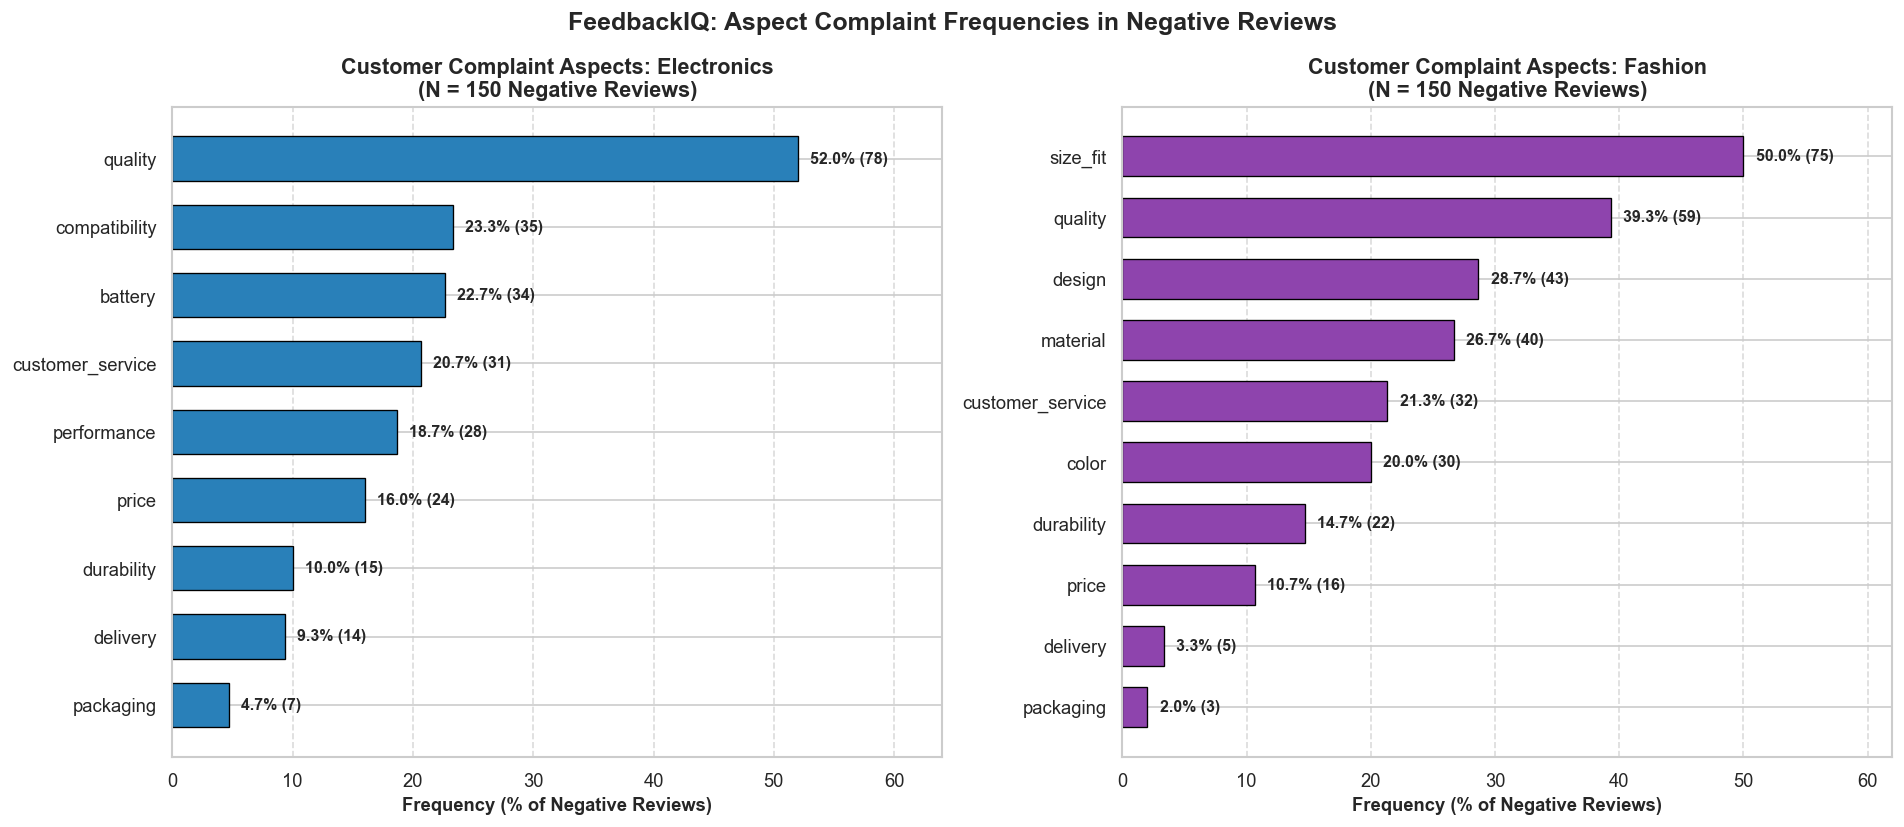

In [7]:
df_freq = pd.read_csv(RESULTS_DIR / "aspect_frequencies.csv")

fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=120)

for idx, domain in enumerate(["Electronics", "Fashion"]):
    ax = axes[idx]
    sub = df_freq[df_freq["domain"] == domain].sort_values("count", ascending=True)

    bars = ax.barh(
        sub["aspect"],
        sub["frequency_pct"],
        color="#2980b9" if domain == "Electronics" else "#8e44ad",
        edgecolor="black",
        linewidth=0.8,
        height=0.65
    )
    ax.set_title(f"Customer Complaint Aspects: {domain}\n(N = 150 Negative Reviews)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Frequency (% of Negative Reviews)", fontsize=11, fontweight="bold")
    ax.set_xlim(0, max(sub["frequency_pct"]) + 12)
    ax.grid(axis="x", linestyle="--", alpha=0.7)

    for bar, count, pct in zip(bars, sub["count"], sub["frequency_pct"]):
        width = bar.get_width()
        ax.text(
            width + 1.0,
            bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}% ({count})",
            va="center",
            ha="left",
            fontsize=9.5,
            fontweight="bold"
        )

plt.suptitle("FeedbackIQ: Aspect Complaint Frequencies in Negative Reviews", fontsize=15, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()


## 8. Business Findings: "What are customers complaining about?"

### 1. Electronics Customers Complain About:
* **Hardware Defect & Failure (52.0%)**: Early mortality of electronics, DOA (dead on arrival) units, and premature breakdowns.
* **Compatibility Roadblocks (23.3%)**: Frustrations with Bluetooth pairing instability, unsupportive app ecosystems (iOS vs. Android), and non-standard cable/port configurations.
* **Rapid Battery Degradation (22.7%)**: Products advertising long battery life that die within 1-2 hours or fail to recharge after minimal cycles.
* **Customer Service & Warranty Friction (20.7%)**: Reluctance of third-party vendors to honor warranties, leaving customers stranded with defective items.

### 2. Fashion Customers Complain About:
* **Size & Fit Inconsistencies (50.0%)**: Misleading manufacturer sizing charts; products arriving significantly smaller or larger than advertised.
* **Tactile Material Quality (26.7%)**: Disappointment with thin, see-through, or scratchy synthetic fabrics when cotton/silk blends were expected.
* **Design & Proportions (28.7%)**: Unflattering cuts, defective stitching/zippers, and awkward silhouettes compared to product model photos.
* **Color Discrepancies (20.0%)**: Colors appearing washed out, completely different from digital listings, or bleeding severely upon the first wash.

### 3. Actionable Business Takeaways:
1. **Electronics Product Strategy**: Introduce pre-purchase compatibility checklists and establish direct warranty replacement workflows.
2. **Fashion Merchandising Strategy**: Implement standardized fit-prediction widgets, mandate true-to-life studio photography, and specify fabric density (GSM).
